In [7]:
# Import torch library and the other usual libraries
# Based on code by Naveen on nomidl.com

import torch
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torchvision import transforms

In [ ]:
# Define a data transformation to convert digit images to tensors
transform = transforms.ToTensor()
# Load the MNIST datasets for training and validation
# images are 28x28 pixel images of handwritten digits in a greyscale
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
valid_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create a data loader for training data with a batch size of 100
train_dl = torch.utils.data.DataLoader(train_dataset, batch_size=100)
# Create a data loader for valid data with a batch size of 100
val_dl = torch.utils.data.DataLoader(valid_dataset, batch_size=100)

In [9]:
# Define the Encoder class for the autoencode
# Input is 28x28, one for each pixel
# Two hidden layers, one with 128 nodes, one with 16
# Latent layer has only 2 nodes! 
# Reduce dimensionality from 784 to 2!
# Layers are linear (fully connected layers with ReLU activation functions)

class Encoder(nn.Module):
    def __init__(self, input_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size1)
        self.fc2 = nn.Linear(hidden_size1, hidden_size2)
        self.fc3 = nn.Linear(hidden_size2, z_dim)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [10]:
# Define the Decoder class for the Variational Autoencoder (VAE)
# Input is 28x28, one for each pixel
# Two hidden layers, one with 128 nodes, one with 16
# Latent layer has only 2 nodes! 
# Reduce dimensionality from 784 to 2!
# Layers are linear (fully connected layers with ReLU activation functions)

class Decoder(nn.Module):
    def __init__(self, output_size=28 * 28, hidden_size1=128, hidden_size2=16, z_dim=2):
        super().__init__()
        self.fc1 = nn.Linear(z_dim, hidden_size2)
        self.fc2 = nn.Linear(hidden_size2, hidden_size1)
        self.fc3 = nn.Linear(hidden_size1, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = torch.sigmoid(self.fc3(x))
        return x

In [11]:
# Check for GPU availability and set the device accordingly
# I don't have a GPU, so device will be 'cpu'

#device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
#print(device)

In [12]:
# GPU for apple sillicon
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(device)

mps


In [13]:
# Initialize the Encoder and Decoder on the selected device (i.e., 'cpu')
enc = Encoder().to(device)
dec = Decoder().to(device)

In [14]:
# Define the loss function (Mean Squared Error) 
# This will be used to compare input to the Encoder with output from the Decoder
loss_fn = nn.MSELoss()

# Select the Adam adaptive gradient descent opitmizer for both Encoder and Decoder
optimizer_enc = torch.optim.Adam(enc.parameters())
optimizer_dec = torch.optim.Adam(dec.parameters())

In [15]:
# We will run for 100/200 training epochs
# store the result from the loss function calculation for each epoch in train_loss[]
train_loss = []
num_epochs = 200

In [16]:
# Note that the training only uses the images
# It does not use the image labels (0,....,9)
# Loop through training epochs
for epoch in range(num_epochs):
    train_epoch_loss = 0
    # Iterate through batches of training data
    for (imgs, _) in train_dl:

# select and flatten the images (28x28 -> 784)
        imgs = imgs.to(device)
        imgs = imgs.flatten(1)
# encode the images to the latent layer
        latents = enc(imgs)
# decode the images to the output layer
        output = dec(latents)
# calculate the loss function
        loss = loss_fn(output, imgs)
# improve Encoder and Decoder weights for this training step
        train_epoch_loss += loss.cpu().detach().numpy()
        optimizer_enc.zero_grad()
        optimizer_dec.zero_grad()
        loss.backward()
        optimizer_enc.step()
        optimizer_dec.step()
# done with training step
# store loss for plotting
    train_loss.append(train_epoch_loss)
    if(epoch % 10 == 0):
        print("Epoch ",epoch, train_loss[epoch])
print("Epoch ",epoch, train_loss[epoch])

Epoch  0 40.881317
Epoch  10 26.140541
Epoch  20 24.44783
Epoch  30 23.662323
Epoch  40 23.113733
Epoch  50 22.920164
Epoch  60 22.584768
Epoch  70 22.36738
Epoch  80 22.317545
Epoch  90 22.17574
Epoch  100 22.14119
Epoch  110 21.891819
Epoch  120 21.80012
Epoch  130 21.765512
Epoch  140 21.628672
Epoch  150 21.607702
Epoch  160 21.552362
Epoch  170 21.681854
Epoch  180 21.581383
Epoch  190 21.493025
Epoch  199 21.558907


In [17]:
print("Epoch ",epoch, train_loss[epoch])
print("relative drop of the loss from epoch 100 to epoch 200:", (train_loss[100] - train_loss[epoch]) / train_loss[100])

Epoch  199 21.558907
relative drop of the loss from epoch 100 to epoch 200: 0.026298633


In [23]:
# --- 验证集 Loss 计算（复制到新 Cell 运行）---
enc.eval()  # 切换到评估模式（关闭 Dropout/BatchNorm 的训练行为）
dec.eval()

val_loss_sum = 0.0
val_samples = 0
val_batch_losses = []

with torch.no_grad():  # 验证时不需要计算梯度，节省内存和算力
    for imgs, _ in val_dl:       # 👈 注意：用 _ 丢弃标签，AE 不需要标签
        imgs = imgs.to(device)
        imgs_flat = imgs.flatten(1)
        
        latent = enc(imgs_flat)
        recon = dec(latent)
        
        loss = loss_fn(recon, imgs_flat)
        val_loss_sum += loss.item() * imgs.size(0)  # 累加总损失
        val_samples += imgs.size(0)
        val_batch_losses.append(loss.item())

val_loss_avg = val_loss_sum / val_samples

import numpy as np
val_loss_std = np.std(val_batch_losses)

# 取训练集最后一个 epoch 的 loss（train_losses 是你训练循环里记录的列表）
last_train_loss = train_loss[-1] / len(train_dl)

relative_change = (val_loss_avg - last_train_loss) / last_train_loss

print(f"训练集最后 Loss: {last_train_loss:.4f}")
print(f"验证集平均 Loss: {val_loss_avg:.4f}")
print(f"验证集 Loss 标准差: {val_loss_std:.4f}")
print(f"相对变化率:      {relative_change:+.4f} ({relative_change*100:+.2f}%)")

enc.train()  # 切回训练模式，避免影响后续操作
dec.train()

训练集最后 Loss: 0.0359
验证集平均 Loss: 0.0379
验证集 Loss 标准差: 0.0039
相对变化率:      +0.0557 (+5.57%)


Decoder(
  (fc1): Linear(in_features=2, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=784, bias=True)
  (relu): ReLU()
)

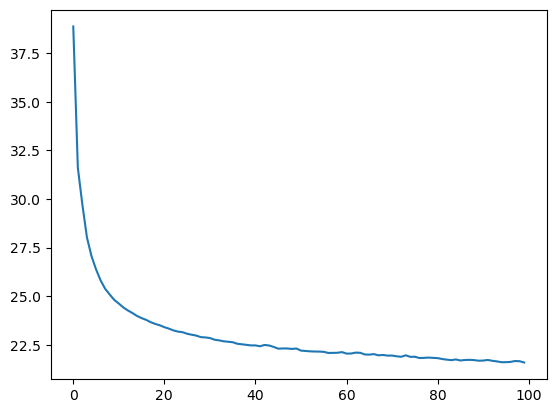

In [10]:
# Plot the training loss over epochs
plt.plot(train_loss)

In [11]:
# Let's have a look now how the images are encoded in the 2D latent space
# Each of the 28x28 images is encoded as one point in the 2D latent space

values = None
all_labels = []

# Generate latent representations for the entire training dataset
# switch off autograd; do not calculate gradients

with torch.no_grad():
    for (imgs, labels) in train_dl:

# send images to device
        imgs = imgs.to(device)
# flatten them
        imgs = imgs.flatten(1)
        all_labels.extend(list(labels.numpy()))
# encode image
        latents = enc(imgs)
        
# store values from latent layer
        if values is None:
            values = latents.cpu()
        else:
            values = torch.vstack([values, latents.cpu()])
# translate values to a numpy array
values = values.numpy()

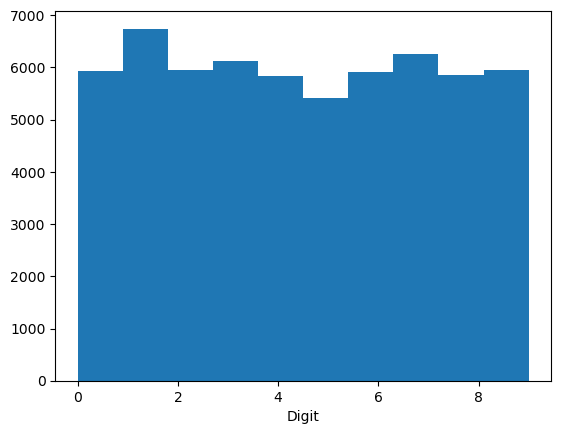

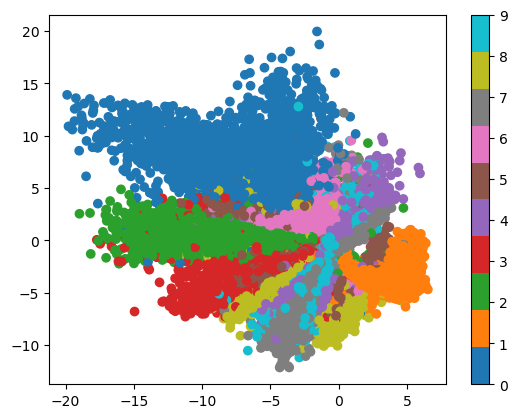

In [ ]:
# all_labels contains labels the handwritten digits from 0 to 9
all_labels = np.array(all_labels)
# we can plot them to see how many examples of each digit we had in the 
# training set
plt.hist(all_labels)
plt.xlabel("Digit")
plt.show()

# Plot the scatter plot of latent space with color-coded labels
# Each dot shows where a particular 28x28 image ends up in the 2D latent space
pc = plt.scatter(values[:, 0], values[:, 1], c=all_labels, cmap='tab10')
plt.colorbar(pc)

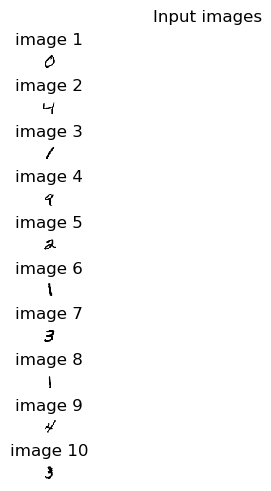

In [ ]:
import matplotlib.gridspec as gridspec

# get a set of images from the data loader
it = iter(train_dl)
xxx,lll = next(it)

# Creating the figure with a constrained layout to avoid axes overlapping
# make grid with 2x10 subplots
fig = plt.figure(constrained_layout = True)
spec = gridspec.GridSpec(ncols=2, nrows=10, figure= fig)
# Setting title
plt.suptitle('Input images')
# plot 9 of the input images
for i in range(1,11,1):
    
    img = transforms.ToPILImage()(xxx[i].reshape(1, 28, 28))
    subplot = fig.add_subplot(spec[i-1,0])
    ax = plt.gca()
    t = "image " + str(i)
    ax.set_title(t) 
    ax.set_axis_off()
    ax.imshow(img, cmap=plt.cm.gray_r, interpolation="nearest")
plt.show()
         

In [ ]:
# map the 28x28 images into the 2D latent space using the encoder in three steps
# send image to device
xxx = xxx.to(device)
# flatten it
xxx = xxx.flatten(1)
# switch off gradient calculation; don't need it when we just want to run encoder and decoder
with torch.no_grad():
# encode image
    latent = enc(xxx)
# for images 1 to 10 print the coordinates in the latent space
    print(latent[1:11])

tensor([[-6.4129,  5.3056],
        [-0.1067,  0.4418],
        [ 4.0944, -3.8269],
        [-1.6261, -2.2205],
        [-7.8314,  1.0328],
        [ 0.4802, -2.4123],
        [-7.4849, -4.7349],
        [ 0.7109, -2.2699],
        [-3.7234, -4.9911],
        [-6.0855, -2.7726]])


Image  1  in latent space:  tensor([-6.4129,  5.3056])
Image  2  in latent space:  tensor([-0.1067,  0.4418])
Image  3  in latent space:  tensor([ 4.0944, -3.8269])
Image  4  in latent space:  tensor([-1.6261, -2.2205])
Image  5  in latent space:  tensor([-7.8314,  1.0328])
Image  6  in latent space:  tensor([ 0.4802, -2.4123])
Image  7  in latent space:  tensor([-7.4849, -4.7349])
Image  8  in latent space:  tensor([ 0.7109, -2.2699])
Image  9  in latent space:  tensor([-3.7234, -4.9911])


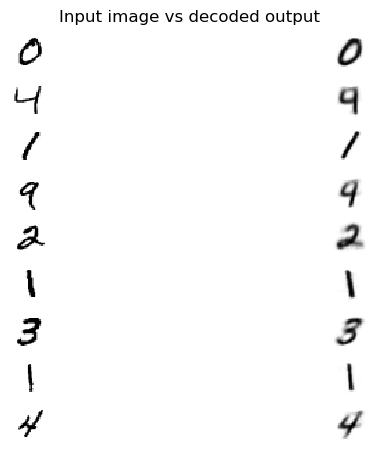

In [ ]:

# Creating the figure with a constrained layout to avoid axes overlapping
# make grid with 2x10 subplots
fig = plt.figure(constrained_layout = True)
spec = gridspec.GridSpec(ncols=2, nrows=10, figure= fig)
# Setting title
plt.suptitle('Input image vs decoded output')

# now take the images and decode from the latent space
# switch off gradient calculation; don't need it when we just want to run encoder and decoder

with torch.no_grad():
    for i in range(1,10,1):
        print("Image ",i," in latent space: ",latent[i])
        img = transforms.ToPILImage()(xxx[i].reshape(1, 28, 28))     
        subplot = fig.add_subplot(spec[i-1,0])
        ax = plt.gca()
        ax.set_axis_off()
        ax.imshow(img, cmap=plt.cm.gray_r, interpolation="nearest")
        
# call decoder to create output image based on coordinate in 2D latent space
        pred = dec(latent[i].to(device)).cpu()
        
#transform image into a PIL Image
        results = transforms.ToPILImage()(pred.reshape(1, 28, 28))
        subplot = fig.add_subplot(spec[i-1,1])
        ax = plt.gca()
        ax.set_axis_off()
#use imshow() to display PIL image
#        ax.imshow(results, cmap=plt.cm.gray_r, interpolation="nearest")
        ax.imshow(results, cmap=plt.cm.gray_r, interpolation="nearest")
    plt.show()

Pick a coordinate from -15 to 15: 2
Pick a coordinate from -20 to 10: 2


Decode [2.0, 2.0] into 28x28 pixel image:


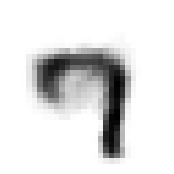

In [ ]:
# Generate an image using two user coordinates in latent space

s = input("Pick a coordinate from -15 to 15:")
x1 = float(s)
s = input("Pick a coordinate from -20 to 10:")
x2 = float(s)
v = [x1,x2]

#switch off autograd; do not calculate gradients
with torch.no_grad():
    print(f"Decode {v} into 28x28 pixel image:")
#use decoder to generate image from 2 coordinates in latent space
    pred = dec(torch.Tensor(v)[None, ...].to(device)).cpu()
#transform image into a PIL Image
    results = transforms.ToPILImage()(pred.reshape(1, 28, 28))
    plt.figure(figsize = (2,2))
    ax = plt.gca()
    ax.set_axis_off()
#use imshow() to display PIL image
    ax.imshow(results, cmap=plt.cm.gray_r, interpolation="nearest")